In [13]:
import glob
import gc
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# import anndata as ad
import scanpy as sc

%matplotlib inline

In [16]:
# Organoids #
ORGANOIDS_PATH = '/mnt/sdb/scz_meta_analysis_processed/anndata_objs'
organoids_filename = 'integrated_adata_annotated_w_celltypist_scanvi.h5ad'
scz_adata = sc.read_h5ad(Path(ORGANOIDS_PATH) / organoids_filename, backed=True)

In [20]:
scz_obs_names = scz_adata[(~scz_adata.obs['pred_dbl'])].obs_names

In [39]:
manuscript_genotype_dict = (scz_adata.obs['Manuscript'].astype('str') + '_' + scz_adata.obs['Broad_Genotype'].astype('str')).to_dict()

In [26]:
# Import Scenic Files #
auc_mtx = pd.read_csv("/mnt/sdb/scz_meta_analysis_processed/scenic_files/auc_mtx.csv") 
auc_mtx.index = scz_obs_names

df_regulons = pd.read_csv("/mnt/sdb/scz_meta_analysis_processed/scenic_files/regulons.csv")

In [ ]:
## port over manuscripts, Donors, Samples, Donor_Samples, Broad_GEnotypes

In [43]:
# Check Manuscripts-Genotypes #
auc_mtx['Manuscript_Genotype'] = auc_mtx.index.map(manuscript_genotype_dict)
auc_mtx_mg = auc_mtx.groupby('Manuscript_Genotype').mean()
top_mgs = (auc_mtx_mg.var(axis=0) / auc_mtx_mg.mean(axis=0)).sort_values(ascending=False)[0:50].index

In [71]:
auc_mtx_mg.loc[['Fernando_Control', 'Fernando_NRXN1del']]

,ARID3A(+),ARX(+),ATF1(+),ATF2(+),ATF3(+),ATF4(+),ATF5(+),BACH1(+),BACH2(+),BARHL1(+),...,ZNF654(+),ZNF669(+),ZNF701(+),ZNF737(+),ZNF75A(+),ZNF774(+),ZSCAN1(+),ZSCAN32(+),ZSCAN9(+),ZXDC(+)
Manuscript_Genotype,,,,,,,,,,,,,,,,,,,,,
Fernando_Control,0.009018,0.032134,0.099757,0.105677,0.002746,0.069844,0.025701,0.035333,0.070379,0.006647,...,0.039446,0.132704,0.019491,0.023163,0.053937,0.035597,0.009160,0.014999,0.008427,0.034274
Fernando_NRXN1del,0.010936,0.043040,0.109539,0.084398,0.004613,0.084519,0.025001,0.029055,0.051188,0.010513,...,0.029332,0.117757,0.024835,0.019261,0.059879,0.025077,0.013047,0.018522,0.012529,0.024442


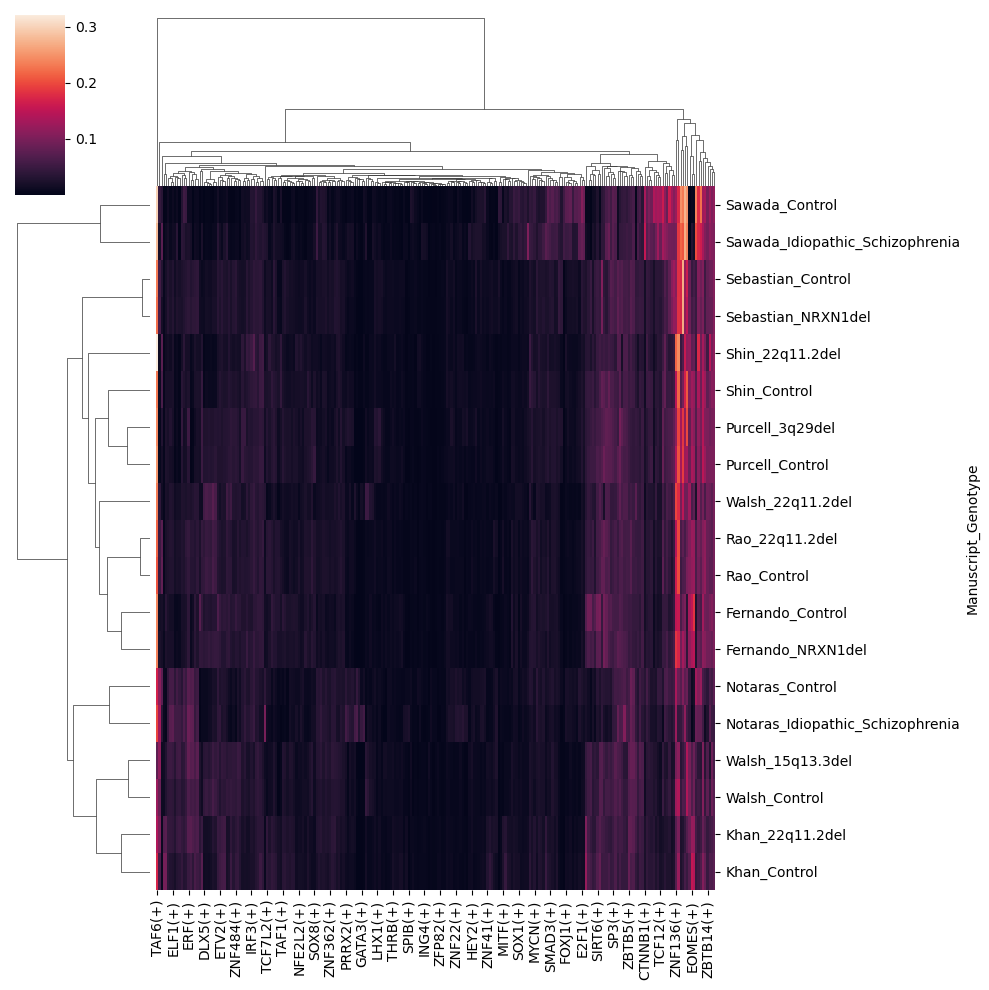

In [69]:
sns.clustermap(auc_mtx_mg)

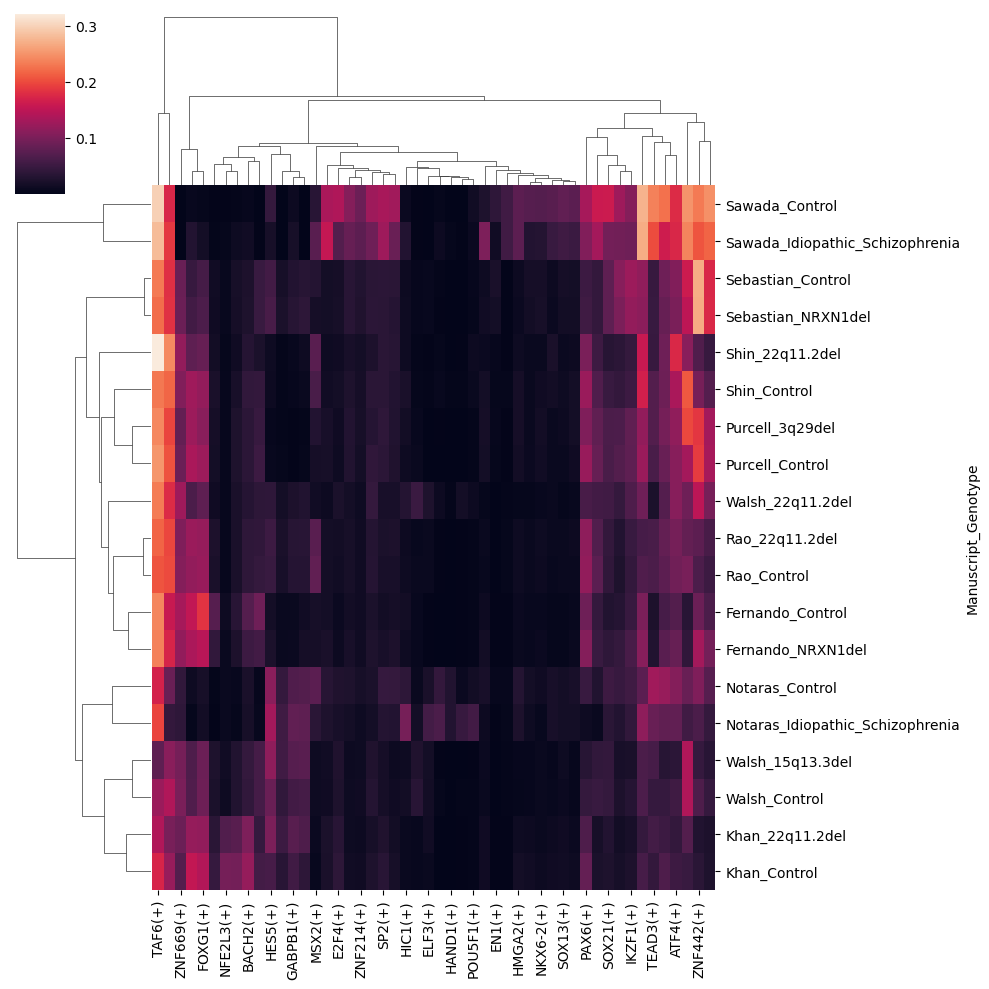

In [68]:
# Highly Variable regulons reveal clustering by Manuscript Is Dominant When You Do This Across The Whole Dataset ##
sns.clustermap(auc_mtx_mg[top_mgs])